In [1]:
# ============================================================================
# CORRECTED CROSS-VALIDATION WITH PROPER NESTED STRUCTURE & HARMONIZATION
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import scipy.stats as stats  
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.metrics import f1_score, precision_score, average_precision_score
from reader import prepare_qsm_dataset
from util import seed_everything, mask_crop as mask_crop_fn
from train import calibrate_balanced
import matplotlib.pyplot as plt

# --- NEW UTILITY FUNCTIONS FOR METRICS ---
def compare_auc_significance(y_true, prob_base, prob_model):
    """Asymptotic comparison of AUCs (DeLong-like approximation)."""
    auc_base = roc_auc_score(y_true, prob_base)
    auc_model = roc_auc_score(y_true, prob_model)
    n1, n0 = sum(y_true == 1), sum(y_true == 0)
    # Variance approximation for the difference
    var_diff = ((auc_base*(1-auc_base) + (n1-1)*(0.1 - auc_base**2) + (n0-1)*(0.1 - auc_base**2)) / (n1*n0)) 
    z = (auc_model - auc_base) / np.sqrt(max(var_diff, 1e-8))
    p_value = 1 - stats.norm.cdf(z)
    return auc_model - auc_base, p_value

def compute_comprehensive_metrics(y_true, y_prob, threshold):
    """Calculates all requested performance metrics."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = recall_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    return {
        'AUC': roc_auc_score(y_true, y_prob),
        'AUPRC': average_precision_score(y_true, y_prob),
        'Acc': accuracy_score(y_true, y_pred),
        'B-Acc': (sens + spec) / 2,
        'Prec': precision_score(y_true, y_pred, zero_division=0),
        'Sens': sens,
        'Spec': spec,
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

# Configuration
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
N_FOLDS = 5
EPOCHS = 100
JITTER_STD = 0.1
IMG_AUG_STD = 0.05
TARGET_DIM = 128
seed_everything(0)

# Architecture and loss classes
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, inputs, targets, weight=None):
        bce = F.binary_cross_entropy(inputs, targets, weight=weight, reduction='none')
        return (self.alpha * (1 - torch.exp(-bce))**self.gamma * bce).mean()

class ClinicalTransformer(nn.Module):
    def __init__(self, n_inputs, embed_dim=32, n_heads=4, n_layers=2):
        super().__init__()
        self.embedding = nn.Linear(1, embed_dim)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim*2, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim * n_inputs, 1)
    def forward(self, x, return_logit=False):
        if x.ndim == 1: x = x.unsqueeze(0)
        x = self.embedding(x.unsqueeze(-1)).permute(1, 0, 2)
        x = self.transformer(x).permute(1, 0, 2).flatten(1)
        logit = self.fc(x).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

class SpectralViT(nn.Module):
    def __init__(self, n_inputs, n_heads=1, embed_dim=32, n_layers=1):
        super().__init__()
        ranks = torch.arange(1, n_inputs + 1, dtype=torch.float32)
        self.rank_weights = nn.Parameter(1.0 / ranks)
        layer = nn.TransformerEncoderLayer(
            d_model=1, 
            nhead=n_heads,
            dim_feedforward=embed_dim*2,
            dropout = 0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.fc = nn.Linear(n_inputs, 1)
    def forward(self, x, return_logit=False):
        x_weighted = x * self.rank_weights
        x_seq = x_weighted.unsqueeze(-1).transpose(0, 1)  # [seq_len, batch, 1]
        x_trans = self.transformer(x_seq)
        x_trans_flat = x_trans.transpose(0, 1).squeeze(-1)  # [batch, n_inputs]
        logit = self.fc(x_trans_flat).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

class SpatialViT(nn.Module):
    def __init__(self, img_size=128, patch_size=16, embed_dim=32, n_heads=1, n_layers=1):
        super().__init__()
        self.patch_size, self.n_patches = patch_size, (img_size // patch_size) ** 2
        self.proj = nn.Linear(patch_size * patch_size, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim*2, dropout=0.1)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim, 1)
    def forward(self, x, return_logit=False):
        b = x.shape[0]
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x = self.proj(x.contiguous().view(b, self.n_patches, -1)) + self.pos_embed
        x = self.transformer(x.permute(1, 0, 2)).permute(1, 0, 2).mean(dim=1)
        logit = self.fc(x).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

class ResidualSpectral(nn.Module):
    def __init__(self, m_ct, m_res):
        super().__init__()
        self.m_ct, self.m_res = m_ct, m_res
    def forward(self, x_res, x_clin, return_logit=False):
        with torch.no_grad(): l_clin = self.m_ct(x_clin, return_logit=True)
        l_res = self.m_res(x_res, return_logit=True)
        joint = l_clin + l_res
        return joint if return_logit else torch.sigmoid(joint)

class ResidualSpatial(nn.Module):
    def __init__(self, m_ct, m_res):
        super().__init__()
        self.m_ct, self.m_res = m_ct, m_res
    def forward(self, x_res, x_clin, return_logit=False):
        with torch.no_grad(): l_clin = self.m_ct(x_clin, return_logit=True)
        l_res = self.m_res(x_res, return_logit=True)
        joint = l_clin + l_res
        return joint if return_logit else torch.sigmoid(joint)

class PassThrough(nn.Module):
    def forward(self, x, **kwargs): return x
    
# Data preparation
def robust_flatten(img_np, target_dim=TARGET_DIM):
    t = torch.from_numpy(img_np).float().unsqueeze(0).unsqueeze(0)
    resized = F.interpolate(t, size=(target_dim, target_dim), mode='bilinear', align_corners=False)
    return resized.numpy().flatten()

def get_slice_level_data(dataset, include_unlabeled=False):
    all_imgs, all_clins, all_lbls, subj_map = [], [], [], []
    for i in range(len(dataset)):
        img, clin, lbl, _ = dataset[i]
        if (i % 72) in [0]: continue
        if (lbl != -1) or (include_unlabeled and lbl == -1):
            all_imgs.append(robust_flatten(img.numpy().squeeze()))
            all_clins.append(clin.numpy()); all_lbls.append(lbl); subj_map.append(i)
    return np.array(all_imgs), np.array(all_clins), np.array(all_lbls), np.array(subj_map)

# ============================================================================
# STEP 1: Load & Harmonize Data
# ============================================================================
dataset_msw = prepare_qsm_dataset('MSW', '/media/mts_dbs/dbs/all/nii/qsm_115/im', '/media/mts_dbs/dbs/all/nii/seg_ps/', '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv', 'msw_cache_6d_cv.pt', load_cache=True, mask_crop_fn=mask_crop_fn, cv_pad=False)
dataset_chh = prepare_qsm_dataset('CHH', '/media/mts_dbs/chh/nii/qsm/', '/media/mts_dbs/chh/roi/', '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv', 'chh_cache_6d_cv.pt', load_cache=True, mask_crop_fn=mask_crop_fn, cv_pad=False)

# Load MSW
X_full_slices, X_full_clin, y_full_slices, full_subj_map = get_slice_level_data(dataset_msw, include_unlabeled=True)
labeled_mask = (y_full_slices != -1)
X_tr_slices = X_full_slices[labeled_mask]
X_tr_clin_raw = X_full_clin[labeled_mask]
y_tr_slices = y_full_slices[labeled_mask]
tr_subj_map = full_subj_map[labeled_mask]

# Load CHH
X_te_slices, X_te_clin_raw, y_te_slices, te_subj_map = get_slice_level_data(dataset_chh)

# --- HARMONIZATION: SITE-SPECIFIC Z-SCORING ---
print("Applying Site-Specific Harmonization...")
scaler_msw = StandardScaler()
X_tr_clin = scaler_msw.fit_transform(X_tr_clin_raw)

scaler_chh = StandardScaler()
X_te_clin = scaler_chh.fit_transform(X_te_clin_raw)
# ---------------------------------------------

NEG_WEIGHT = float(sum(y_tr_slices==1) // sum(y_tr_slices==0))
GAMMA = NEG_WEIGHT

# ============================================================================
# STEP 2: HYPERPARAMETER SELECTION
# ============================================================================
print("\n" + "="*60)
print("STEP 2: HYPERPARAMETER SELECTION")
print("="*60)

unique_subjs = np.unique(tr_subj_map)
y_unique = np.array([y_tr_slices[tr_subj_map == s][0] for s in unique_subjs])
outer_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)
criterion = FocalLoss(gamma=GAMMA)

# 1. OPTIMIZE POS_WEIGHT USING CLINICAL TRANSFORMER
pos_weight_grid = [0.1, 0.25, 0.5, 0.75, 1.0]
weight_results = {k: [] for k in pos_weight_grid}

print("\n--- Phase 1: Optimizing pos_weight via Clinical Transformer ---")
for pos_weight in pos_weight_grid:
    fold_aucs = []
    for fold_idx, (train_subj_idx, val_subj_idx) in enumerate(outer_skf.split(unique_subjs, y_unique)):
        train_subjects, val_subjects = unique_subjs[train_subj_idx], unique_subjs[val_subj_idx]
        train_mask, val_mask = np.isin(tr_subj_map, train_subjects), np.isin(tr_subj_map, val_subjects)
        
        # Data is already harmonized/scaled
        X_train_clin_t = torch.tensor(X_tr_clin[train_mask], dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_tr_slices[train_mask], dtype=torch.float32).to(device)
        X_val_clin_t = torch.tensor(X_tr_clin[val_mask], dtype=torch.float32).to(device)
        y_val = y_tr_slices[val_mask]
        
        model = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-4)
        w = torch.where(y_train_t == 0, torch.tensor(NEG_WEIGHT, device=device), torch.tensor(pos_weight, device=device))
        
        for epoch in range(EPOCHS):
            model.train()
            optimizer.zero_grad()
            X_jitter = X_train_clin_t + torch.randn_like(X_train_clin_t) * JITTER_STD
            loss = criterion(model(X_jitter), y_train_t, weight=w)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_probs = model(X_val_clin_t).cpu().numpy()
            val_subj_probs = [val_probs[tr_subj_map[val_mask] == s].mean() for s in val_subjects]
            val_subj_labels = [y_val[tr_subj_map[val_mask] == s][0] for s in val_subjects]
            fold_aucs.append(roc_auc_score(val_subj_labels, val_subj_probs))
    
    weight_results[pos_weight] = fold_aucs
    print(f"  Pos Weight={pos_weight}: AUC = {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

SELECTED_POS_WEIGHT = pos_weight_grid[np.argmin([np.std(weight_results[pw]) for pw in pos_weight_grid])]
print(f"✓ Selected positive weight: {SELECTED_POS_WEIGHT}")

# 2. OPTIMIZE N_COMPONENTS USING RESIDUAL SPECTRAL MODEL
pca_components_grid = [16, 32, 64, 128]
pca_results = {k: [] for k in pca_components_grid}

print("\n--- Phase 2: Optimizing n_components via Residual PCA Model ---")
for n_comp in pca_components_grid:
    fold_aucs = []
    for fold_idx, (train_subj_idx, val_subj_idx) in enumerate(outer_skf.split(unique_subjs, y_unique)):
        train_subjects, val_subjects = unique_subjs[train_subj_idx], unique_subjs[val_subj_idx]
        train_mask, val_mask = np.isin(tr_subj_map, train_subjects), np.isin(tr_subj_map, val_subjects)
        
        # Preprocessing (Img only, clin is already done)
        f_img_scaler = StandardScaler().fit(X_tr_slices[train_mask])
        f_pca = PCA(n_components=n_comp, random_state=0, whiten=True).fit(f_img_scaler.transform(X_tr_slices[train_mask]))
        
        X_tr_clin_t = torch.tensor(X_tr_clin[train_mask], dtype=torch.float32).to(device)
        X_tr_pca_t = torch.tensor(f_pca.transform(f_img_scaler.transform(X_tr_slices[train_mask])), dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_tr_slices[train_mask], dtype=torch.float32).to(device)
        
        X_val_clin_t = torch.tensor(X_tr_clin[val_mask], dtype=torch.float32).to(device)
        X_val_pca_t = torch.tensor(f_pca.transform(f_img_scaler.transform(X_tr_slices[val_mask])), dtype=torch.float32).to(device)
        y_val = y_tr_slices[val_mask]
        
        # Train residual model (CT + Spectral)
        m_ct = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
        opt_ct = optim.Adam(m_ct.parameters(), lr=1e-4)
        w = torch.where(y_train_t == 0, torch.tensor(NEG_WEIGHT, device=device), torch.tensor(SELECTED_POS_WEIGHT, device=device))
        for _ in range(50):
            m_ct.train(); opt_ct.zero_grad()
            loss = criterion(m_ct(X_tr_clin_t + torch.randn_like(X_tr_clin_t)*JITTER_STD), y_train_t, weight=w)
            loss.backward(); opt_ct.step()
        m_ct.eval(); [p.requires_grad_(False) for p in m_ct.parameters()]

        model = ResidualSpectral(m_ct, SpectralViT(n_inputs=n_comp)).to(device)
        optimizer = optim.Adam(model.m_res.parameters(), lr=5e-4)
        
        for epoch in range(EPOCHS):
            model.train(); optimizer.zero_grad()
            loss = criterion(model(X_tr_pca_t, X_tr_clin_t), y_train_t, weight=w)
            loss.backward(); optimizer.step()
            
        model.eval()
        with torch.no_grad():
            val_probs = model(X_val_pca_t, X_val_clin_t).cpu().numpy()
            val_subj_probs = [val_probs[tr_subj_map[val_mask] == s].mean() for s in val_subjects]
            val_subj_labels = [y_val[tr_subj_map[val_mask] == s][0] for s in val_subjects]
            fold_aucs.append(roc_auc_score(val_subj_labels, val_subj_probs))
            
    pca_results[n_comp] = fold_aucs
    print(f"  PCA={n_comp}: AUC = {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

N_PCA_COMPONENTS = pca_components_grid[np.argmax([np.mean(pca_results[n]) for n in pca_components_grid])]
print(f"✓ Selected PCA components: {N_PCA_COMPONENTS}")

# ============================================================================
# STEP 3: FINAL CROSS-VALIDATION
# ============================================================================
print("\n" + "="*60)
print("STEP 3: FINAL CROSS-VALIDATION EVALUATION")
print("="*60)

eval_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)
clinical_fold_weights = []
all_cv_probs_ct, all_cv_probs_sp, all_cv_probs_va, all_cv_labels = [], [], [], []
fold_preds_ct, fold_preds_sp, fold_preds_spatial = [], [], []
fold_thresholds_ct, fold_thresholds_sp, fold_thresholds_va = [], [], []

for fold_idx, (train_subj_idx, val_subj_idx) in enumerate(eval_skf.split(unique_subjs, y_unique)):
    print(f"--- Fold {fold_idx + 1}/{N_FOLDS} ---")
    train_mask, val_mask = np.isin(tr_subj_map, unique_subjs[train_subj_idx]), np.isin(tr_subj_map, unique_subjs[val_subj_idx])
    
    f_img_scaler = StandardScaler().fit(X_tr_slices[train_mask])
    f_pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0, whiten=True).fit(f_img_scaler.transform(X_tr_slices[train_mask]))
    
    X_train_pca = f_pca.transform(f_img_scaler.transform(X_tr_slices[train_mask]))
    X_train_clin = X_tr_clin[train_mask]
    X_train_img = X_tr_slices[train_mask]
    y_train = y_tr_slices[train_mask]
    
    X_val_pca, X_val_clin, X_val_img, y_val = f_pca.transform(f_img_scaler.transform(X_tr_slices[val_mask])), X_tr_clin[val_mask], X_tr_slices[val_mask], y_tr_slices[val_mask]
    X_test_pca, X_test_clin, X_test_img = f_pca.transform(f_img_scaler.transform(X_te_slices)), X_te_clin, X_te_slices

    X_train_clin_t, X_train_pca_t = torch.tensor(X_train_clin, dtype=torch.float32).to(device), torch.tensor(X_train_pca, dtype=torch.float32).to(device)
    X_train_img_t = torch.tensor(X_train_img).view(-1, 1, 128, 128).float().to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
    w = torch.where(y_train_t == 0, torch.tensor(NEG_WEIGHT, device=device), torch.tensor(SELECTED_POS_WEIGHT, device=device))
    
    # Train Models
    m_ct = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
    opt_ct = optim.Adam(m_ct.parameters(), lr=1e-4)
    for _ in range(EPOCHS):
        m_ct.train(); opt_ct.zero_grad()
        loss = criterion(m_ct(X_train_clin_t + torch.randn_like(X_train_clin_t)*JITTER_STD), y_train_t, weight=w)
        loss.backward(); opt_ct.step()
    m_ct.eval(); [p.requires_grad_(False) for p in m_ct.parameters()]
    clinical_fold_weights.append(m_ct.state_dict())
    m_sp = ResidualSpectral(m_ct, SpectralViT(n_inputs=N_PCA_COMPONENTS)).to(device)
    opt_sp = optim.Adam(m_sp.m_res.parameters(), lr=1e-4)
    for _ in range(EPOCHS):
        m_sp.train(); opt_sp.zero_grad()
        loss = criterion(m_sp(X_train_pca_t + torch.randn_like(X_train_pca_t)*IMG_AUG_STD, X_train_clin_t), y_train_t, weight=w)
        loss.backward(); opt_sp.step()

    m_va = ResidualSpatial(m_ct, SpatialViT()).to(device)
    opt_va = optim.Adam(m_va.m_res.parameters(), lr=1e-4)
    for _ in range(EPOCHS):
        m_va.train(); opt_va.zero_grad()
        loss = criterion(m_va(X_train_img_t + torch.randn_like(X_train_img_t)*IMG_AUG_STD, X_train_clin_t), y_train_t, weight=w)
        loss.backward(); opt_va.step()

    # Evaluation
    with torch.no_grad():
        v_probs_ct, v_probs_sp, v_probs_va, v_labels = [], [], [], []
        for s in unique_subjs[val_subj_idx]:
            m = (tr_subj_map[val_mask] == s)
            v_probs_ct.append(m_ct(torch.tensor(X_val_clin[m], dtype=torch.float32).to(device)).mean().item())
            v_probs_sp.append(m_sp(torch.tensor(X_val_pca[m], dtype=torch.float32).to(device), torch.tensor(X_val_clin[m], dtype=torch.float32).to(device)).mean().item())
            v_probs_va.append(m_va(torch.tensor(X_val_img[m]).view(-1, 1, 128, 128).float().to(device), torch.tensor(X_val_clin[m], dtype=torch.float32).to(device)).mean().item())
            v_labels.append(y_val[m][0])
        
        fold_thresholds_ct.append(calibrate_balanced(PassThrough(), None, np.array(v_probs_ct), np.array(v_labels), 'cpu'))
        fold_thresholds_sp.append(calibrate_balanced(PassThrough(), None, np.array(v_probs_sp), np.array(v_labels), 'cpu'))
        fold_thresholds_va.append(calibrate_balanced(PassThrough(), None, np.array(v_probs_va), np.array(v_labels), 'cpu'))
        all_cv_probs_ct.extend(v_probs_ct); all_cv_probs_sp.extend(v_probs_sp); all_cv_probs_va.extend(v_probs_va); all_cv_labels.extend(v_labels)

        t_probs_ct, t_probs_sp, t_probs_va = [], [], []
        for s in np.unique(te_subj_map):
            m = (te_subj_map == s)
            t_probs_ct.append(m_ct(torch.tensor(X_test_clin[m], dtype=torch.float32).to(device)).mean().item())
            t_probs_sp.append(m_sp(torch.tensor(X_test_pca[m], dtype=torch.float32).to(device), torch.tensor(X_test_clin[m], dtype=torch.float32).to(device)).mean().item())
            t_probs_va.append(m_va(torch.tensor(X_test_img[m]).view(-1, 1, 128, 128).float().to(device), torch.tensor(X_test_clin[m], dtype=torch.float32).to(device)).mean().item())
        fold_preds_ct.append(t_probs_ct); fold_preds_sp.append(t_probs_sp); fold_preds_spatial.append(t_probs_va)

# Final calculation logic remains the same
th_ct, th_sp, th_va = np.mean(fold_thresholds_ct), np.mean(fold_thresholds_sp), np.mean(fold_thresholds_va)
y_test_labels = np.array([y_te_slices[te_subj_map == s][0] for s in np.unique(te_subj_map)])

# Aggregated Probabilities
cv_probs = {"Clinical": all_cv_probs_ct, "Spectral": all_cv_probs_sp, "Spatial": all_cv_probs_va}
test_probs = {
    "Clinical": np.mean(fold_preds_ct, axis=0),
    "Spectral": np.mean(fold_preds_sp, axis=0),
    "Spatial": np.mean(fold_preds_spatial, axis=0)
}
thresholds = {"Clinical": th_ct, "Spectral": th_sp, "Spatial": th_va}

def print_results_table(title, labels, prob_dict, thresh_dict):
    print(f"\n{title}")
    header = f"{'Model':<12} | {'AUC':<5} | {'AUPRC':<6} | {'Acc':<5} | {'B-Acc':<5} | {'Prec':<5} | {'Sens':<5} | {'Spec':<5} | {'F1':<5}"
    print("-" * len(header))
    print(header)
    print("-" * len(header))
    for name in ["Clinical", "Spectral", "Spatial"]:
        m = compute_comprehensive_metrics(np.array(labels), np.array(prob_dict[name]), thresh_dict[name])
        print(f"{name:<12} | {m['AUC']:.3f} | {m['AUPRC']:.3f} | {m['Acc']:.3f} | {m['B-Acc']:.3f} | {m['Prec']:.3f} | {m['Sens']:.3f} | {m['Spec']:.3f} | {m['F1']:.3f}")
    
    print("\nStatistical Significance (Incremental value over Clinical):")
    for name in ["Spectral", "Spatial"]:
        diff, p = compare_auc_significance(np.array(labels), np.array(prob_dict["Clinical"]), np.array(prob_dict[name]))
        sig = "*" if p < 0.05 else "n.s."
        print(f"  {name:<8} vs Clinical: ΔAUC {diff:+.3f}, p={p:.4f} ({sig})")

# Final Output
print_results_table("INTERNAL VALIDATION (5-Fold CV)", all_cv_labels, cv_probs, thresholds)
print_results_table("EXTERNAL TEST PERFORMANCE (CHH Dataset)", y_test_labels, test_probs, thresholds)

print("\n✓ Pipeline finished with comprehensive evaluation.")


Preparing MSW dataset (Forced 6-dim alignment) 
Pre-flight check: Validating MSW CSV mapping...
--- MSW CSV RAW MEANS ---
  > Age     : 62.13
  > Sex     : 0.26
  > Dur     : 8.47
  > LEDD    : 989.80
  > Off-Pre : 45.91
  > On-Pre  : 19.60

Final MSW Breakdown:
 - Unique Subjects on Disk: 111
 - Labeled Responders (1): 61
 - Labeled Non-Responders (0): 5
 - Unlabeled subjects (-1): 45
 - Verified Realized Means (Matched Data Only):
    > Age     : 63.08
    > Sex     : 0.26
    > Dur     : 8.44
    > LEDD    : 1003.95
    > Off-Pre : 45.62
    > On-Pre  : 19.55

❌ FULL MISSING LIST (45 subjects):
  [3, 4, 5, 8, 12, 13, 14, 17, 18, 21, 22, 24, 25, 27, 28, 31, 32, 34, 35, 37, 39, 40, 41, 42, 49, 50, 52, 54, 57, 61, 65, 67, 74, 76, 81, 82, 84, 88, 89, 94, 99, 101, 104, 105, 116]
Loaded cache with 7790 slices.

Preparing CHH dataset (Forced 6-dim alignment) 
Pre-flight check: Validating CHH CSV mapping...
--- CHH CSV RAW MEANS ---
  > Age     : 63.13
  > Sex     : 0.46
  > Dur     : 8.54

In [5]:
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, Sampler
from torch.cuda.amp import GradScaler, autocast
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score

# High-speed hardware optimization
torch.backends.cudnn.benchmark = True

# --- Numerical Stable Focal Loss for AMP ---
def stable_focal_loss(logits, targets, alpha=1, gamma=2):
    bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    pt = torch.exp(-bce_loss)
    f_loss = alpha * (1 - pt)**gamma * bce_loss
    return f_loss.mean()

# 0. Structural Memory Flush
if 'm_un' in locals(): del m_un
torch.cuda.empty_cache()
gc.collect()

# --- Fast Small U-Net Classifier ---
class FastUNet(nn.Module):
    def __init__(self, in_channels=1, out_classes=1):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )
        
        # Encoder
        self.enc1 = conv_block(in_channels, 16)
        self.enc2 = conv_block(16, 32)
        self.pool = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = conv_block(32, 64)
        
        # Simple Global Pooling Classifier
        self.gmp = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, out_classes)
        )
        nn.init.zeros_(self.fc[-1].weight)
        nn.init.zeros_(self.fc[-1].bias)

    def forward(self, x):
        # Direct path for maximum speed
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        bn = self.bottleneck(self.pool(x2))
        pooled = self.gmp(bn).view(x.size(0), -1)
        return self.fc(pooled).squeeze(-1)

# ============================================================================
# SEPARATE CELL: FAST U-NET RESIDUAL TRAINING & FULL RESULTS
# ============================================================================

if 'm_un_res' in locals(): del m_un_res
torch.cuda.empty_cache()
gc.collect()

all_cv_probs_un = []
fold_preds_un = []
fold_ths_un = []
scaler_amp = GradScaler() 

for fold, (t_subj_idx, v_subj_idx) in enumerate(eval_skf.split(unique_subjs, y_unique)):
    print(f"Fold {fold+1} Fast U-Net Training | Progress: ", end='', flush=True)
    
    t_mask = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
    scaler_c = StandardScaler().fit(X_tr_clin[t_mask])
    
    m_ct_fold = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
    m_ct_fold.load_state_dict(clinical_fold_weights[fold])
    m_ct_fold.eval()

    with torch.no_grad():
        xt_c_gpu = torch.tensor(scaler_c.transform(X_tr_clin[t_mask]), dtype=torch.float32).to(device)
        t_clin_logits = m_ct_fold(xt_c_gpu, return_logit=True).detach()

    # Pre-load entire fold to GPU VRAM for zero-latency loading
    xt_i_gpu = torch.tensor(X_tr_slices[t_mask]).view(-1, 1, 128, 128).float().to(device)
    yt_gpu = torch.tensor(y_tr_slices[t_mask], dtype=torch.float32).to(device)
    
    pos_idx = torch.where(yt_gpu == 1)[0]
    neg_idx = torch.where(yt_gpu == 0)[0]
    batch_size = 64 # Increased batch size for 2080 Ti efficiency
    half_batch = batch_size // 2
    num_batches = len(pos_idx) // half_batch

    m_un_res = FastUNet().to(device)
    optimizer = optim.Adam(m_un_res.parameters(), lr=5e-4) # Higher LR for faster convergence

    # Training Loop
    for epoch in range(EPOCHS):
        m_un_res.train()
        shuffled_neg =neg_idx[torch.randperm(len(neg_idx))]
        
        for i in range(num_batches):
            n_ids = shuffled_neg[i*half_batch : (i+1)*half_batch]
            p_ids = pos_idx[torch.randint(0, len(pos_idx), (half_batch,))]
            b_idx = torch.cat([p_ids, n_ids])
            
            b_i = xt_i_gpu[b_idx]
            b_clin_l = t_clin_logits[b_idx]
            b_y = yt_gpu[b_idx]
            
            optimizer.zero_grad(set_to_none=True) 
            with autocast():
                # Fast augmentation
                res_logit = m_un_res(b_i + torch.randn_like(b_i) * IMG_AUG_STD)
                joint_logit = res_logit + b_clin_l
                
                bce_loss = F.binary_cross_entropy_with_logits(joint_logit, b_y, reduction='none')
                w_batch = torch.where(b_y == 0, torch.tensor(NEG_WEIGHT, device=device), torch.tensor(SELECTED_POS_WEIGHT, device=device))
                loss = (w_batch * (1 - torch.exp(-bce_loss))**GAMMA * bce_loss).mean()
            
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
            
        if (epoch + 1) % 25 == 0: print(f'{epoch+1}..', end='', flush=True)
    print('Done.')

    # Inference
    m_un_res.eval()
    with torch.no_grad():
        v_un, v_lbls = [], []
        for s_id in unique_subjs[v_subj_idx]:
            sm = (tr_subj_map == s_id)
            c_v = torch.tensor(scaler_c.transform(X_tr_clin[sm]), dtype=torch.float32).to(device)
            i_v = torch.tensor(X_tr_slices[sm]).view(-1, 1, 128, 128).float().to(device)
            l_c = m_ct_fold(c_v, return_logit=True)
            v_un.append(torch.sigmoid(l_c + m_un_res(i_v)).mean().item())
            v_lbls.append(y_tr_slices[sm][0])
            
        fold_ths_un.append(calibrate_balanced(PassThrough(), None, np.array(v_un), np.array(v_lbls), 'cpu'))
        all_cv_probs_un.extend(v_un)

        t_un = []
        for s_id in np.unique(te_subj_map):
            sm = (te_subj_map == s_id)
            c_t = torch.tensor(scaler_c.transform(X_te_clin[sm]), dtype=torch.float32).to(device)
            i_t = torch.tensor(X_te_slices[sm]).view(-1, 1, 128, 128).float().to(device)
            l_c_t = m_ct_fold(c_t, return_logit=True)
            t_un.append(torch.sigmoid(l_c_t + m_un_res(i_t)).mean().item())
        fold_preds_un.append(t_un)

    #del m_un_res, m_ct_fold
    torch.cuda.empty_cache()

# --- REPRINT COMPREHENSIVE TABLE WITH ALL MODELS ---
cv_probs["Attention U-Net"] = all_cv_probs_un
test_probs["Attention U-Net"] = np.mean(fold_preds_un, axis=0)
thresholds["Attention U-Net"] = np.mean(fold_ths_un)

def print_final_combined_table(title, labels, prob_dict, thresh_dict):
    print(f"\n{title}")
    header = f"{'Model':<16} | {'AUC':<5} | {'AUPRC':<6} | {'Acc':<5} | {'B-Acc':<5} | {'Prec':<5} | {'Sens':<5} | {'Spec':<5} | {'F1':<5}"
    print("-" * len(header))
    print(header)
    print("-" * len(header))

    for name in ["Clinical", "Spectral", "Spatial", "Attention U-Net"]:
        m = compute_comprehensive_metrics(np.array(labels), np.array(prob_dict[name]), thresh_dict[name])
        print(f"{name:<16} | {m['AUC']:.3f} | {m['AUPRC']:.3f} | {m['Acc']:.3f} | {m['B-Acc']:.3f} | {m['Prec']:.3f} | {m['Sens']:.3f} | {m['Spec']:.3f} | {m['F1']:.3f}")

    print("\nStatistical Significance (vs Clinical):")
    for name in ["Spectral", "Spatial", "Attention U-Net"]:
        diff, p = compare_auc_significance(np.array(labels), np.array(prob_dict["Clinical"]), np.array(prob_dict[name]))
        sig = "*" if p < 0.05 else "n.s."
        print(f"  {name:<16}: ΔAUC {diff:+.3f}, p={p:.4f} ({sig})")

print_final_combined_table("INTERNAL VALIDATION (5-Fold CV)", all_cv_labels, cv_probs, thresholds)
print_final_combined_table("EXTERNAL TEST PERFORMANCE (CHH Dataset)", y_test_labels, test_probs, thresholds)

Fold 1 Fast U-Net Training | Progress: 25..50..75..100..Done.
Fold 2 Fast U-Net Training | Progress: 25..50..75..100..Done.
Fold 3 Fast U-Net Training | Progress: 25..50..75..100..Done.
Fold 4 Fast U-Net Training | Progress: 25..50..75..100..Done.
Fold 5 Fast U-Net Training | Progress: 25..50..75..100..Done.

INTERNAL VALIDATION (5-Fold CV)
---------------------------------------------------------------------------------
Model            | AUC   | AUPRC  | Acc   | B-Acc | Prec  | Sens  | Spec  | F1   
---------------------------------------------------------------------------------
Clinical         | 0.820 | 0.982 | 0.673 | 0.738 | 0.977 | 0.661 | 0.814 | 0.789
Spectral         | 0.804 | 0.980 | 0.655 | 0.727 | 0.976 | 0.642 | 0.811 | 0.775
Spatial          | 0.817 | 0.982 | 0.638 | 0.736 | 0.981 | 0.621 | 0.851 | 0.760
Attention U-Net  | 0.825 | 0.983 | 0.667 | 0.747 | 0.981 | 0.653 | 0.842 | 0.784

Statistical Significance (vs Clinical):
  Spectral        : ΔAUC -0.016, p=1.0000 (n.s

In [6]:
from sklearn.linear_model import LogisticRegression
import torch.optim as optim

# 1. Model Definition for PCA+Clinical MLP
class PCAClinMLP(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_inputs, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x, return_logit=False):
        logit = self.net(x).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

# Initialize storage for new baselines
cv_probs_lr, cv_probs_mlp = [], []
fold_preds_lr, fold_preds_mlp = [], []
fold_ths_lr, fold_ths_mlp = [], []

print("\n" + "="*60)
print("RUNNING PCA BASELINES (LR & MLP)")
print("="*60)

for fold_idx, (train_subj_idx, val_subj_idx) in enumerate(eval_skf.split(unique_subjs, y_unique)):
    print(f"Fold {fold_idx + 1} Baselines...", end=' ', flush=True)
    
    # --- Data Preparation (Matching your nested CV logic) ---
    train_mask = np.isin(tr_subj_map, unique_subjs[train_subj_idx])
    val_mask = np.isin(tr_subj_map, unique_subjs[val_subj_idx])
    
    # Re-fit PCA/Scaler exactly as in Step 3
    f_img_scaler = StandardScaler().fit(X_tr_slices[train_mask])
    f_pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0, whiten=True).fit(
        f_img_scaler.transform(X_tr_slices[train_mask])
    )
    
    # Create Combined Features [PCA | Clinical]
    def get_comb(slices, clin):
        pca_feats = f_pca.transform(f_img_scaler.transform(slices))
        return np.hstack([pca_feats, clin])

    X_train_comb = get_comb(X_tr_slices[train_mask], X_tr_clin[train_mask])
    y_train = y_tr_slices[train_mask]
    
    # --- 1. Logistic Regression ---
    clf_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)
    clf_lr.fit(X_train_comb, y_train)
    
    # --- 2. PCA + MLP ---
    m_mlp = PCAClinMLP(n_inputs=X_train_comb.shape[1]).to(device)
    opt_mlp = optim.Adam(m_mlp.parameters(), lr=1e-4)
    
    xt_comb_gpu = torch.tensor(X_train_comb, dtype=torch.float32).to(device)
    yt_gpu = torch.tensor(y_train, dtype=torch.float32).to(device)
    w_mlp = torch.where(yt_gpu==0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(SELECTED_POS_WEIGHT).to(device))
    
    for _ in range(EPOCHS):
        m_mlp.train(); opt_mlp.zero_grad()
        # Apply jitter to combined vector for robustness
        noise = torch.randn_like(xt_comb_gpu) * JITTER_STD
        loss = criterion(m_mlp(xt_comb_gpu + noise), yt_gpu, weight=w_mlp)
        loss.backward(); opt_mlp.step()

    # --- 3. Calibration & Inference ---
    m_mlp.eval()
    with torch.no_grad():
        v_m, v_l, v_lbls = [], [], []
        for s in unique_subjs[val_subj_idx]:
            m = (tr_subj_map[val_mask] == s)
            v_comb = get_comb(X_tr_slices[val_mask][m], X_tr_clin[val_mask][m])
            v_comb_t = torch.tensor(v_comb, dtype=torch.float32).to(device)
            
            v_m.append(m_mlp(v_comb_t).mean().item())
            v_l.append(clf_lr.predict_proba(v_comb)[:, 1].mean())
            v_lbls.append(y_tr_slices[val_mask][m][0])

        cv_probs_mlp.extend(v_m); cv_probs_lr.extend(v_l)
        fold_ths_mlp.append(calibrate_balanced(PassThrough(), None, np.array(v_m), np.array(v_lbls), 'cpu'))
        fold_ths_lr.append(calibrate_balanced(PassThrough(), None, np.array(v_l), np.array(v_lbls), 'cpu'))

        # Test Set (CHH)
        t_m_subj, t_l_subj = [], []
        for s in np.unique(te_subj_map):
            m = (te_subj_map == s)
            te_comb = get_comb(X_te_slices[m], X_te_clin[m])
            t_m_subj.append(m_mlp(torch.tensor(te_comb, dtype=torch.float32).to(device)).mean().item())
            t_l_subj.append(clf_lr.predict_proba(te_comb)[:, 1].mean())
        fold_preds_mlp.append(t_m_subj); fold_preds_lr.append(t_l_subj)
    
    print("Done.")

# --- 4. Update Global Dictionary and Reprint Table ---
cv_probs.update({"PCA+LR": cv_probs_lr, "PCA+MLP": cv_probs_mlp})
test_probs.update({"PCA+LR": np.mean(fold_preds_lr, axis=0), "PCA+MLP": np.mean(fold_preds_mlp, axis=0)})
thresholds.update({"PCA+LR": np.mean(fold_ths_lr), "PCA+MLP": np.mean(fold_ths_mlp)})

def print_master_table(title, labels, prob_dict, thresh_dict):
    print(f"\n{title}")
    header = f"{'Model':<16} | {'AUC':<5} | {'AUPRC':<6} | {'Acc':<5} | {'B-Acc':<5} | {'Sens':<5} | {'Spec':<5} | {'F1':<5}"
    print("-" * len(header))
    print(header)
    print("-" * len(header))
    # Order models from baseline to advanced
    for name in ["Clinical", "PCA+LR", "PCA+MLP", "Spectral", "Spatial", "Attention U-Net"]:
        if name in prob_dict:
            m = compute_comprehensive_metrics(np.array(labels), np.array(prob_dict[name]), thresh_dict[name])
            print(f"{name:<16} | {m['AUC']:.3f} | {m['AUPRC']:.3f} | {m['Acc']:.3f} | {m['B-Acc']:.3f} | {m['Sens']:.3f} | {m['Spec']:.3f} | {m['F1']:.3f}")

print_master_table("FINAL INTERNAL VALIDATION (5-Fold CV)", all_cv_labels, cv_probs, thresholds)
print_master_table("FINAL EXTERNAL TEST (CHH Dataset)", y_test_labels, test_probs, thresholds)


RUNNING PCA BASELINES (LR & MLP)
Fold 1 Baselines... Done.
Fold 2 Baselines... Done.
Fold 3 Baselines... Done.
Fold 4 Baselines... Done.
Fold 5 Baselines... Done.

FINAL INTERNAL VALIDATION (5-Fold CV)
-------------------------------------------------------------------------
Model            | AUC   | AUPRC  | Acc   | B-Acc | Sens  | Spec  | F1   
-------------------------------------------------------------------------
Clinical         | 0.820 | 0.982 | 0.673 | 0.738 | 0.661 | 0.814 | 0.789
PCA+LR           | 0.950 | 0.996 | 0.851 | 0.894 | 0.844 | 0.944 | 0.913
PCA+MLP          | 0.569 | 0.944 | 0.475 | 0.526 | 0.466 | 0.586 | 0.622
Spectral         | 0.804 | 0.980 | 0.655 | 0.727 | 0.642 | 0.811 | 0.775
Spatial          | 0.817 | 0.982 | 0.638 | 0.736 | 0.621 | 0.851 | 0.760
Attention U-Net  | 0.825 | 0.983 | 0.667 | 0.747 | 0.653 | 0.842 | 0.784

FINAL EXTERNAL TEST (CHH Dataset)
-------------------------------------------------------------------------
Model            | AUC   | A

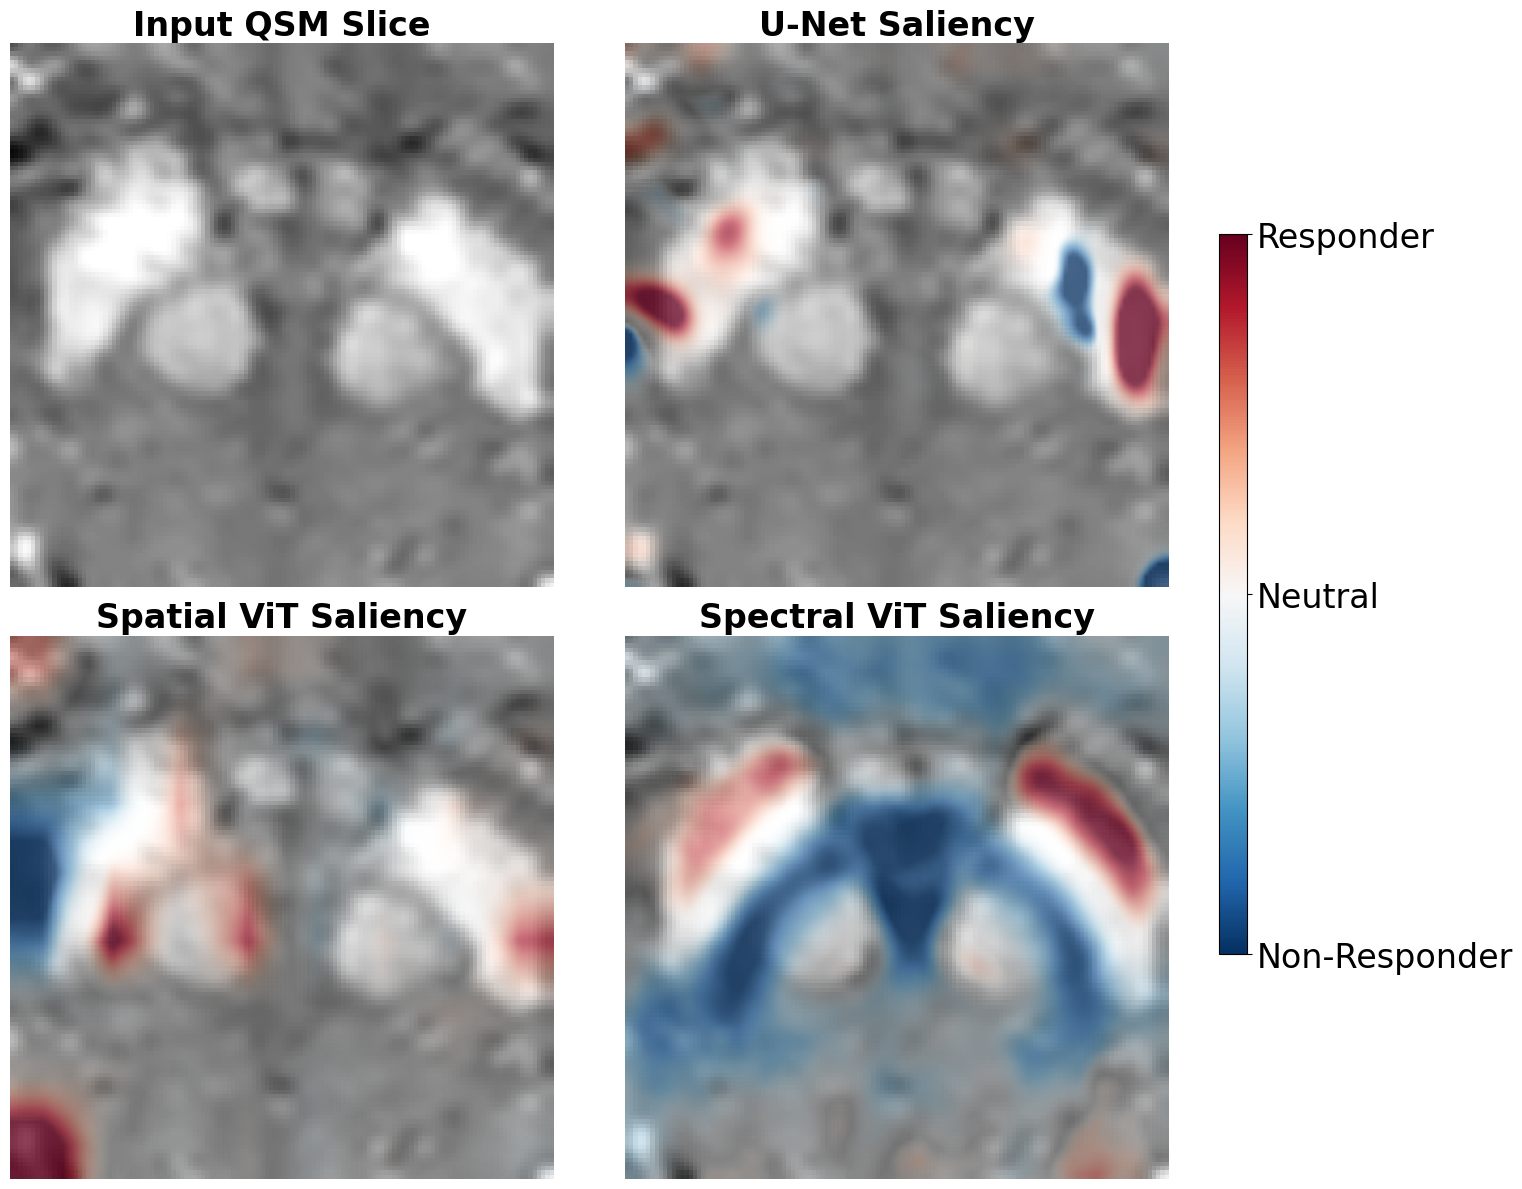

In [25]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
import torch.nn.functional as F

def viz_clinical_residual_saliency(f_pca, m_sp, m_va, m_un, X_te_raw, X_te_pca, idx=40, global_alpha=0.75, num_samples=25):
    """
    Visualization using SmoothGrad, heavy Gaussian smoothing, and LINEAR alpha.
    Designed to highlight broader regions and eliminate sparse white artifacts.
    """
    m_sp.eval(); m_va.eval(); m_un.eval()
    device = next(m_un.parameters()).device
    
    # --- 1. Data Preparation ---
    xi_t = torch.from_numpy(X_te_raw[idx:idx+1]).view(-1, 1, 128, 128).float().to(device)
    xp_t = torch.from_numpy(X_te_pca[idx:idx+1]).float().to(device).requires_grad_(True)

    # --- 2. Saliency: Fast U-Net with SmoothGrad (Higher Samples for Stability) ---
    # std_dev helps the model focus on robust features across noise variations
    std_dev = 0.15 * (xi_t.max() - xi_t.min()).item()
    grad_accumulator = torch.zeros_like(xi_t)
    
    for _ in range(num_samples):
        noise = torch.randn_like(xi_t) * std_dev
        xi_noisy = (xi_t + noise).clone().detach().requires_grad_(True)
        
        m_un.zero_grad()
        output = m_un(xi_noisy)
        
        # Determine score based on output dimensionality
        if output.dim() > 1 and output.shape[1] > 1:
            score = output[:, 1].sum() 
        else:
            score = output.sum()
            
        grad = torch.autograd.grad(score, xi_noisy)[0]
        grad_accumulator += grad
    
    avg_grad = grad_accumulator / num_samples
    unet_raw = (avg_grad * xi_t).detach().cpu().numpy().squeeze()
    
    # --- HEAVY SMOOTHING ---
    # Increased sigma to 3.5 to merge points into regional heatmaps
    unet_map = gaussian_filter(unet_raw, sigma=3.5)

    # --- 3. Saliency: Spectral ViT ---
    raw_w = m_sp.m_res.fc.weight.detach().cpu().numpy().squeeze()
    rank_w = m_sp.m_res.rank_weights.detach().cpu().numpy()
    pca_sal = raw_w * rank_w * xp_t.detach().cpu().numpy().squeeze()
    
    spec_map = np.zeros(f_pca.components_.shape[1])
    for i in range(len(pca_sal)):
        spec_map += pca_sal[i] * f_pca.components_[i]
    spec_map = spec_map.reshape(128, 128)
    
    # --- 4. Saliency: Spatial ViT ---
    with torch.no_grad():
        b, p_size, n_p = xi_t.shape[0], m_va.m_res.patch_size, m_va.m_res.n_patches
        x = xi_t.unfold(2, p_size, p_size).unfold(3, p_size, p_size)
        x = m_va.m_res.proj(x.contiguous().view(b, n_p, -1)) + m_va.m_res.pos_embed
        
        _, attn_weights = m_va.m_res.transformer.layers[0].self_attn(
            x.permute(1, 0, 2), x.permute(1, 0, 2), x.permute(1, 0, 2)
        )
        spat_attn = attn_weights.mean(dim=1).view(b, int(np.sqrt(n_p)), int(np.sqrt(n_p)))
        spat_map = F.interpolate(spat_attn.unsqueeze(1), size=(128, 128), mode='bilinear').squeeze().cpu().numpy()
        spat_map -= spat_map.mean() 

    # --- 5. Normalization & Plotting ---
    def independent_polar_norm(img, p=99.0):
        pos_m, neg_m = img > 0, img < 0
        v_max = np.percentile(img[pos_m], p) if np.any(pos_m) else (np.max(img) if np.any(img > 0) else 1e-12)
        v_min = np.percentile(img[neg_m], 100-p) if np.any(neg_m) else (np.min(img) if np.any(img < 0) else -1e-12)
        normed = np.zeros_like(img)
        if np.any(pos_m): normed[pos_m] = img[pos_m] / v_max
        if np.any(neg_m): normed[neg_m] = -img[neg_m] / v_min 
        return np.clip(normed, -1, 1)

    maps = [unet_map, spat_map, spec_map]
    titles = ["U-Net Saliency", "Spatial ViT Saliency", "Spectral ViT Saliency"]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), facecolor='white')
    bg = np.rot90(X_te_raw[idx].reshape(128, 128), k=1)
    cmap = plt.get_cmap("RdBu_r")
    norm = mcolors.Normalize(vmin=-1, vmax=1)

    axes[0, 0].imshow(bg, cmap='gray', vmin=-1, vmax=1)
    axes[0, 0].set_title("Input QSM Slice", fontweight='bold', fontsize=24)
    axes[0, 0].axis('off')

    for i, (m, title) in enumerate(zip(maps, titles)):
        ax = axes.flatten()[i+1]
        m_normed = independent_polar_norm(m, p=98.0)
        m_rot = np.rot90(m_normed, k=1)
        
        ax.imshow(bg, cmap='gray', vmin=-1, vmax=1)
        rgba = cmap(norm(m_rot))
        
        # --- STRICT LINEAR ALPHA ---
        # Linear relationship: Higher intensity = less transparent
        rgba[:, :, 3] = np.abs(m_rot) * global_alpha
        
        ax.imshow(rgba, interpolation='bilinear')
        ax.set_title(title, fontweight='bold',fontsize=24)
        ax.axis('off')

    plt.tight_layout()
    fig.subplots_adjust(right=0.85, wspace=0.1)
    
    cbar_ax = fig.add_axes([0.88, 0.2, 0.02, 0.6])
    cbar_ax.tick_params(labelsize=24)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_ticks([-1, 0, 1])
    cbar.set_ticklabels(['Non-Responder', 'Neutral', 'Responder'])
    
    plt.show()

# Run the visualization
viz_clinical_residual_saliency(f_pca, m_sp, m_va, m_un_res, X_te_slices, X_test_pca, idx=37, global_alpha=0.75)

Optimal Consensus Slice (within +/- 2 of center): 2663
Clinical Status: RESPONDER


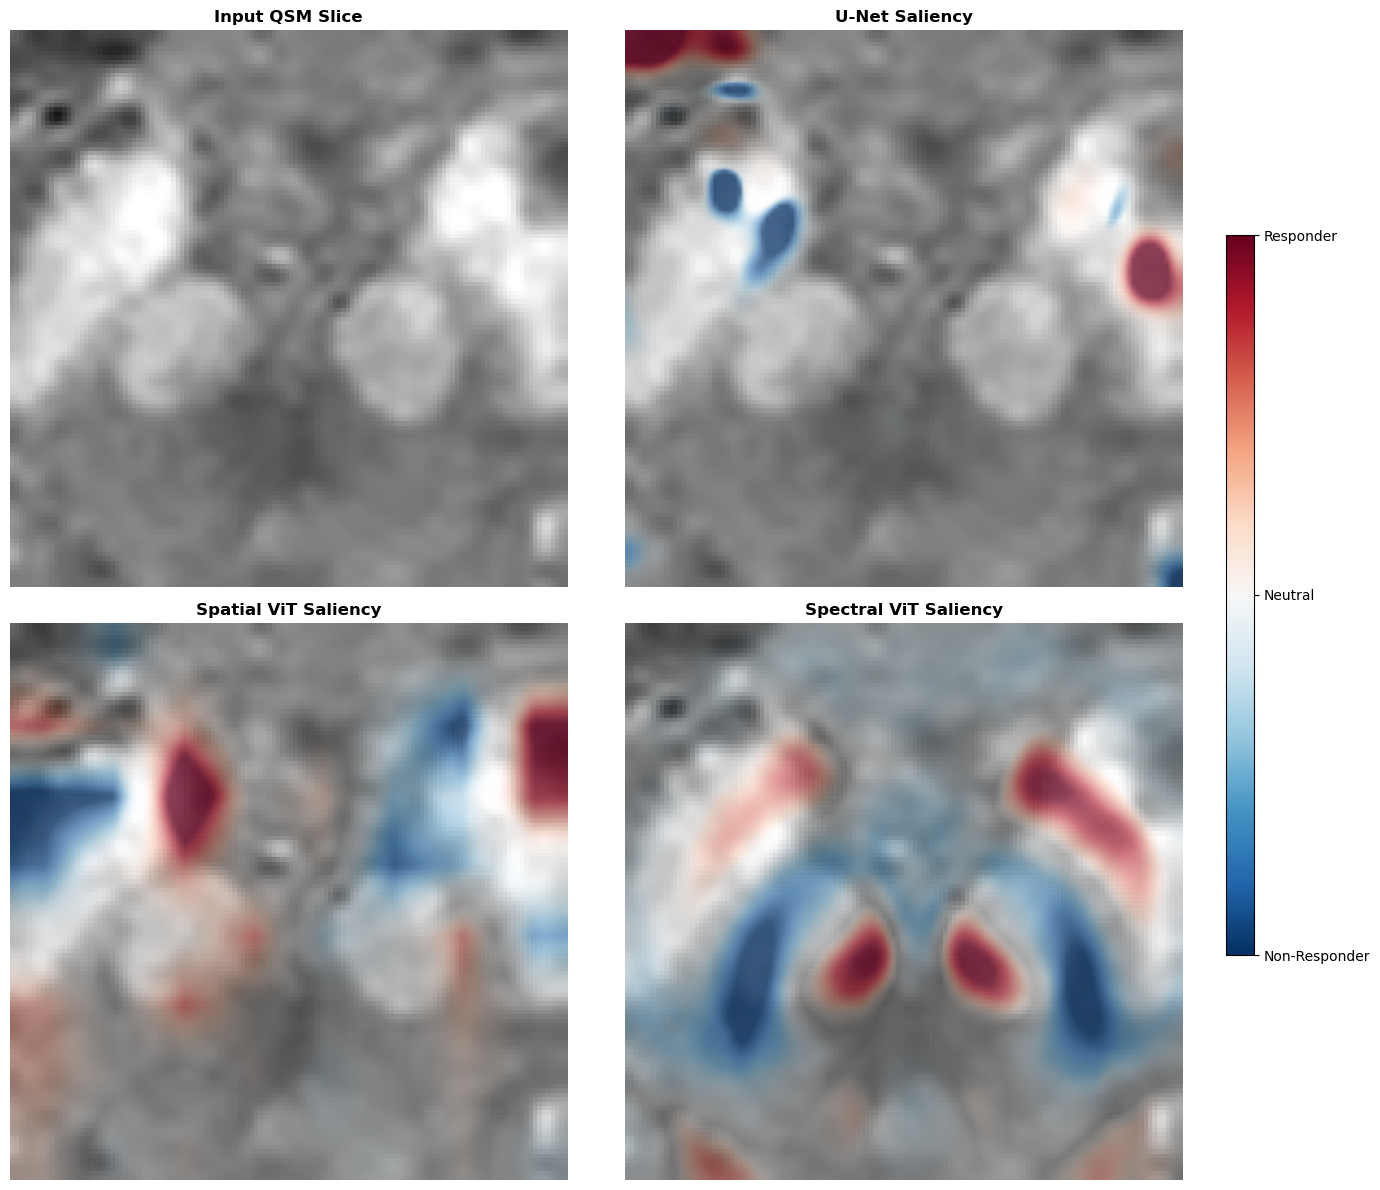

<Figure size 640x480 with 0 Axes>

In [15]:
def find_most_agreed_slice(f_pca, m_sp, m_va, m_un, X_te_raw, X_te_pca, subj_idx, slices_per_subj=71):
    """
    Identifies the best slice within the middle +/- 2 slices of a subject.
    """
    m_sp.eval(); m_va.eval(); m_un.eval()
    device = next(m_un.parameters()).device
    
    # Calculate the central slice index for this subject
    subj_start = subj_idx * slices_per_subj
    central_rel_idx = slices_per_subj // 2
    
    # Define the 5-slice window: [center-2, center-1, center, center+1, center+2]
    search_window = range(central_rel_idx - 2, central_rel_idx + 3)
    
    consensus_scores = []
    global_indices = []

    for rel_idx in search_window:
        idx = subj_start + rel_idx
        global_indices.append(idx)
        
        # --- 1. U-Net Saliency ---
        xi_t = torch.from_numpy(X_te_raw[idx:idx+1]).view(-1, 1, 128, 128).float().to(device).requires_grad_(True)
        
        with torch.enable_grad():
            out_un = m_un(xi_t)
            # Targeting single node or class 1
            score_un = out_un[:, 1].sum() if out_un.dim() > 1 and out_un.shape[1] > 1 else out_un.sum()
            grad_un = torch.autograd.grad(score_un, xi_t)[0]
        
        un_map = np.abs(grad_un.detach().cpu().numpy().squeeze())
        un_map = (un_map - un_map.min()) / (un_map.max() + 1e-8)

        # --- 2. Spatial ViT Attention ---
        with torch.no_grad():
            b, p_size, n_p = xi_t.shape[0], m_va.m_res.patch_size, m_va.m_res.n_patches
            x = xi_t.unfold(2, p_size, p_size).unfold(3, p_size, p_size)
            x = m_va.m_res.proj(x.contiguous().view(b, n_p, -1)) + m_va.m_res.pos_embed
            _, attn = m_va.m_res.transformer.layers[0].self_attn(x.permute(1,0,2), x.permute(1,0,2), x.permute(1,0,2))
            
            grid_size = int(np.sqrt(attn.shape[-1])) 
            spat_map = F.interpolate(attn.mean(1).view(b, 1, grid_size, grid_size), 
                                   size=(128,128), mode='bilinear').cpu().numpy().squeeze()
            spat_map = (spat_map - spat_map.min()) / (spat_map.max() + 1e-8)

            # --- 3. Spectral ViT Projection ---
            xp_t = torch.from_numpy(X_te_pca[idx:idx+1]).float().to(device)
            raw_w = m_sp.m_res.fc.weight.detach().cpu().numpy().squeeze()
            spec_feat = xp_t.cpu().numpy().squeeze()
            spec_map = np.abs((raw_w * spec_feat) @ f_pca.components_).reshape(128, 128)
            spec_map = (spec_map - spec_map.min()) / (spec_map.max() + 1e-8)

        # Voxel-wise consensus product
        consensus = un_map * spat_map * spec_map
        consensus_scores.append(np.sum(consensus))

    # Identify the global index of the winner within that 5-slice window
    best_idx = global_indices[np.argmax(consensus_scores)]
    return best_idx

# --- Execution ---
subject_to_check = 37 
best_idx = find_most_agreed_slice(f_pca, m_sp, m_va, m_un_res, X_te_slices, X_test_pca, subject_to_check)

# 1. Determine the label and color
gt_val = y_te_slices[best_idx]
label_text = "RESPONDER" if gt_val == 1 else "NON-RESPONDER"
label_color = "green" if gt_val == 1 else "red"

print(f"Optimal Consensus Slice (within +/- 2 of center): {best_idx}")
print(f"Clinical Status: {label_text}")

# 2. Run your visualization
viz_clinical_residual_saliency(f_pca, m_sp, m_va, m_un_res, X_te_slices, X_test_pca, idx=best_idx)

# 3. Add the bold label to the top of the plot
plt.gcf().text(0.5, 0.96, f"Subject {subject_to_check + 1} | True Status: {label_text}", 
               fontsize=16, ha='center', fontweight='bold', color=label_color)

plt.show()

In [9]:
import torch
import numpy as np

def identify_spectral_corrections(test_probs, test_labels, thresholds, x_clin_raw, x_slices, te_subj_map, scaler_chh):
    """
    Identifies subjects where Spectral model was correct and Clinical was wrong.
    Uses ensemble probabilities and ground truth labels from the external set.
    """
    # 1. Extract ensemble predictions and ground truth
    y_true = np.array(test_labels)
    p_ct = test_probs["Clinical"]
    p_sp = test_probs["Spectral"]
    
    # 2. Apply calibrated thresholds to identify discrete classes
    #
    y_pred_ct = (p_ct >= thresholds["Clinical"]).astype(int)
    y_pred_sp = (p_sp >= thresholds["Spectral"]).astype(int)
    
    # 3. Identify Discrepancy: Clinical Wrong AND Spectral Right
    # This captures both saved False Negatives and saved False Positives
    clin_wrong = (y_pred_ct != y_true)
    spec_right = (y_pred_sp == y_true)
    corrected_mask = clin_wrong & spec_right
    
    corrected_indices = np.where(corrected_mask)[0]
    unique_subjs = np.unique(te_subj_map)
    
    print(f"=== Spectral Recovery Analysis (External CHH Set) ===")
    print(f"Total Unique Subjects: {len(y_true)}")
    print(f"Subjects Corrected by Spectral Imaging: {len(corrected_indices)}")
    print(f"{'-' * 75}")
    
    if len(corrected_indices) > 0:
        print(f"{'Subj_ID':<10} | {'Label':<6} | {'Clin Prob':<10} | {'Spec Prob':<10} | {'Category'}")
        print(f"{'-' * 75}")
        
        for idx in corrected_indices:
            subj_id = unique_subjs[idx]
            label_str = "Resp" if y_true[idx] == 1 else "Non-R"
            
            # Identify if it was a recovered FN (Clinical missed a responder) 
            # or a recovered FP (Clinical wrongly flagged a non-responder)
            if y_true[idx] == 1:
                category = "Recovered FN (Found Responder)"
            else:
                category = "Recovered FP (Avoided False Alarm)"
                
            print(f"{str(subj_id):<10} | {label_str:<6} | {p_ct[idx]:.4f}    | {p_sp[idx]:.4f}    | {category}")
    else:
        print("No subjects found where Spectral corrected a Clinical error.")

    return corrected_indices

# --- Execution using variables from your provided pipeline ---
#
corrected_ids = identify_spectral_corrections(
    test_probs, 
    y_test_labels, 
    thresholds, 
    X_te_clin_raw, 
    X_te_slices, 
    te_subj_map, 
    scaler_chh
)

# Optional: Print raw counts of the types of corrections
if len(corrected_ids) > 0:
    recovered_fns = sum(y_test_labels[corrected_ids] == 1)
    recovered_fps = sum(y_test_labels[corrected_ids] == 0)
    print(f"\nSummary of Improvement:")
    print(f" - Responders correctly identified by Image data: {recovered_fns}")
    print(f" - Non-Responders correctly identified by Image data: {recovered_fps}")

=== Spectral Recovery Analysis (External CHH Set) ===
Total Unique Subjects: 2840
Subjects Corrected by Spectral Imaging: 102
---------------------------------------------------------------------------
Subj_ID    | Label  | Clin Prob  | Spec Prob  | Category
---------------------------------------------------------------------------
160        | Resp   | 0.2025    | 0.2141    | Recovered FN (Found Responder)
164        | Resp   | 0.2001    | 0.2096    | Recovered FN (Found Responder)
168        | Resp   | 0.1902    | 0.2135    | Recovered FN (Found Responder)
171        | Resp   | 0.2018    | 0.2229    | Recovered FN (Found Responder)
188        | Resp   | 0.2087    | 0.2116    | Recovered FN (Found Responder)
203        | Resp   | 0.2024    | 0.2223    | Recovered FN (Found Responder)
205        | Resp   | 0.1993    | 0.2111    | Recovered FN (Found Responder)
371        | Resp   | 0.2077    | 0.2140    | Recovered FN (Found Responder)
382        | Resp   | 0.2050    | 0.2103    | Rec

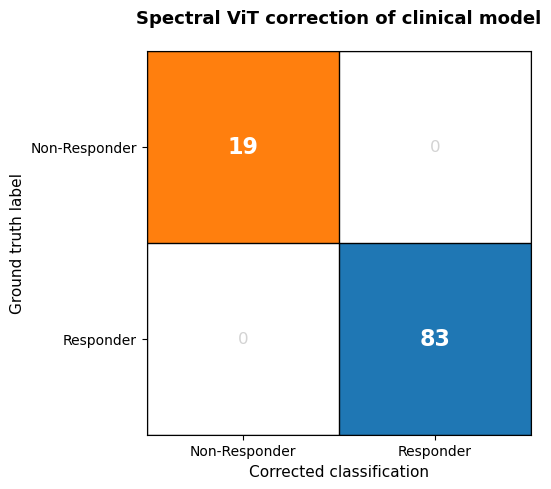

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

def plot_correction_matrix_custom(test_probs, test_labels, thresholds):
    """
    Plots the 'Value-Add' matrix with tab:orange for Non-Responders 
    and tab:blue for Responders.
    """
    y_true = np.array(test_labels)
    
    # 1. Generate discrete predictions
    y_pred_ct = (test_probs["Clinical"] >= thresholds["Clinical"]).astype(int)
    y_pred_sp = (test_probs["Spectral"] >= thresholds["Spectral"]).astype(int)
    
    # 2. Identify the recovery counts
    # Value 1: Avoided False Alarm (Non-Responder)
    avoid_fa = ((y_pred_ct == 1) & (y_true == 0) & (y_pred_sp == 0)).sum()
    
    # Value 2: Recovered Responder
    rec_resp = ((y_pred_ct == 0) & (y_true == 1) & (y_pred_sp == 1)).sum()
    
    # Create the matrix. We use 1 and 2 as "keys" for the colors
    # [ [Non-R Key, Empty], [Empty, Responder Key] ]
    display_matrix = np.array([[1 if avoid_fa > 0 else 0, 0], 
                                [0, 2 if rec_resp > 0 else 0]])
    
    # Values for annotations
    text_matrix = np.array([[avoid_fa, 0], [0, rec_resp]])
    
    # 3. Create Custom Colormap: [Index 0: White, Index 1: Orange, Index 2: Blue]
    cmap_custom = ListedColormap(['white', 'tab:orange', 'tab:blue'])
    labels = ['Non-Responder', 'Responder']

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')
    im = ax.imshow(display_matrix, cmap=cmap_custom, vmin=0, vmax=2)

    # Add text annotations
    for i in range(2):
        for j in range(2):
            val = text_matrix[i, j]
            if val > 0:
                ax.text(j, i, f"{val}", ha="center", va="center", 
                        color="white", fontsize=16, fontweight='bold')
            else:
                ax.text(j, i, "0", ha="center", va="center", 
                        color="lightgray", fontsize=12)

    # Formatting
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    
    ax.set_xlabel("Corrected classification", fontsize=11)
    ax.set_ylabel("Ground truth label", fontsize=11)
    ax.set_title("Spectral ViT correction of clinical model", 
                 fontsize=13, fontweight='bold', pad=20)
    
    # Grid lines to separate cells clearly
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.show()

# Execution
plot_correction_matrix_custom(test_probs, y_test_labels, thresholds)